In [1]:
# Cell 0 - Mount Google Drive and copy the dataset to the local runtime
# Copying the dataset locally avoids the I/O overhead of reading thousands
# of small image files directly from Google Drive during training.

from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DATA_PATH = "/content/drive/MyDrive/extracted_frames/frames"
LOCAL_DATA_PATH = "/content/frames"

if not os.path.exists(LOCAL_DATA_PATH):
    print("Copying dataset from Drive to local runtime. This may take a few minutes...")
    !cp -r "{DRIVE_DATA_PATH}" "{LOCAL_DATA_PATH}"
    print("Copy complete.")
else:
    print("Local dataset already present. Skipping copy.")

print("Local dataset root:", LOCAL_DATA_PATH)

Mounted at /content/drive
Copying dataset from Drive to local runtime. This may take a few minutes...
Copy complete.
Local dataset root: /content/frames


In [2]:
# Cell 1 - Imports

import io
import os
import copy
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")

print("PyTorch :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch : 2.11.0+cu128
CUDA available: True


In [3]:
# Cell 2 - Hyperparameters and configuration

DATASET_ROOT = "/content/frames"
OUTPUT_DIR   = "/content/outputs_fft"

IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 10
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 3
SEED          = 42
NUM_WORKERS   = 0
NUM_CLASSES   = 2
FFT_LOG_SCALE = True
RGB_ALPHA     = 0.5   # 0 = pure RGB, 1 = pure FFT magnitude

CKPT_PLAIN = os.path.join(OUTPUT_DIR, "ckpt_plain_fft.pth")
CKPT_RGB   = os.path.join(OUTPUT_DIR, "ckpt_fft_rgb.pth")

CLASS_NAMES  = ["ai_videos", "real_videos"]
CLASS_LABELS = {"ai_videos": 0, "real_videos": 1}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device       :", DEVICE)
print("Dataset root :", DATASET_ROOT)
print("Outputs      :", OUTPUT_DIR)

Device       : cuda
Dataset root : /content/frames
Outputs      : /content/outputs_fft


In [4]:
# Cell 3 - Model 1: plain_fft
# Contains the shared FFTResNet18 architecture (also reused by Model 2),
# the plain FFT transform, the dataset class, and the loader builder.

_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]


# ---- Shared model architecture -----------------------------------------

class FFTResNet18(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, freeze_backbone=False):
        super().__init__()
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        in_f = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_f, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


def build_fft_resnet18(freeze_backbone=False):
    model = FFTResNet18(num_classes=NUM_CLASSES, pretrained=True,
                         freeze_backbone=freeze_backbone)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,}")
    return model.to(DEVICE)


# ---- Shared augmentation -------------------------------------------------

class JpegCompression:
    def __init__(self, quality_range=(70, 100)):
        self.quality_range = quality_range

    def __call__(self, img_pil):
        quality = random.randint(*self.quality_range)
        buf = io.BytesIO()
        img_pil.save(buf, format="JPEG", quality=quality)
        buf.seek(0)
        return Image.open(buf).copy()


def get_train_transforms():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        JpegCompression(quality_range=(70, 100)),
    ])


# ---- Model 1 FFT transform -----------------------------------------------

def fft_to_3channel(img_rgb_np, img_size, log_scale=True):
    img   = img_rgb_np.astype(np.float32)
    gray  = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    fft_g = np.fft.fftshift(np.fft.fft2(gray))
    fft_G = np.fft.fftshift(np.fft.fft2(img[:, :, 1]))
    mag_g = np.log1p(np.abs(fft_g)) if log_scale else np.abs(fft_g)
    mag_G = np.log1p(np.abs(fft_G)) if log_scale else np.abs(fft_G)
    phase = (np.angle(fft_g) + np.pi) / (2 * np.pi)

    def _nr(a):
        a = a - a.min()
        a = a / (a.max() + 1e-8)
        return cv2.resize(a, (img_size, img_size),
                           interpolation=cv2.INTER_LINEAR).astype(np.float32)

    return np.stack([_nr(mag_g), _nr(mag_G), _nr(phase)], axis=0)


# ---- Model 1 dataset -------------------------------------------------------

class FFTFrameDataset(Dataset):

    EXTS = {".jpg", ".jpeg", ".png"}

    def __init__(self, root, split, augment=False, fft_transform=None):
        self.augment       = augment
        self.fft_transform = fft_transform or fft_to_3channel
        self.samples       = []

        for cls_name, cls_idx in CLASS_LABELS.items():
            actual_folder_name = "ai" if "ai" in cls_name.lower() else "real"
            folder = Path(root) / split / actual_folder_name

            if not folder.exists():
                print(f"[WARN] Folder not found: {folder}")
                continue

            found = [str(p) for p in folder.rglob("*") if p.suffix.lower() in self.EXTS]
            self.samples.extend([(p, cls_idx) for p in found])
            print(f"[{split.upper()}] Loaded {len(found)} frames for class '{cls_name}'")

        self.spatial_aug = get_train_transforms() if augment else None
        self.normalize   = transforms.Normalize(mean=_MEAN, std=_STD)
        print(f"  [FFTFrameDataset / {split}] Total: {len(self.samples)} | augment={augment}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        if self.spatial_aug:
            img = self.spatial_aug(img)
        out = self.fft_transform(np.array(img), IMG_SIZE, log_scale=FFT_LOG_SCALE)
        return self.normalize(torch.from_numpy(out)), label


# ---- Model 1 loader builder ------------------------------------------------

def build_loaders_plain():
    train_ds = FFTFrameDataset(DATASET_ROOT, "train", augment=True,  fft_transform=fft_to_3channel)
    val_ds   = FFTFrameDataset(DATASET_ROOT, "val",   augment=False, fft_transform=fft_to_3channel)
    test_ds  = FFTFrameDataset(DATASET_ROOT, "test",  augment=False, fft_transform=fft_to_3channel)

    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)
    va_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    te_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} | Batch: {BATCH_SIZE}")
    return tr_loader, va_loader, te_loader


print("Model 1 (plain_fft) components loaded.")

Model 1 (plain_fft) components loaded.


In [5]:
# Cell 4 - Model 2: fft_rgb
# Reuses FFTResNet18, JpegCompression, and get_train_transforms from Cell 3.
# Only the transform and dataset are specific to this variant.

def rgb_fft_blend(img_rgb_np, img_size, alpha=0.5, log_scale=True):
    img  = img_rgb_np.astype(np.float32) / 255.0
    img  = cv2.resize(img, (img_size, img_size))
    gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    fft  = np.fft.fftshift(np.fft.fft2(gray))
    mag  = np.log1p(np.abs(fft)) if log_scale else np.abs(fft)
    mag  = (mag - mag.min()) / (mag.max() + 1e-8)
    mag  = cv2.resize(mag, (img_size, img_size))

    blended = img.copy()
    for c in range(3):
        blended[:, :, c] = (1 - alpha) * img[:, :, c] + alpha * mag
    return np.clip(blended, 0, 1).transpose(2, 0, 1).astype(np.float32)


class RGBFFTDataset(Dataset):

    EXTS = {".jpg", ".jpeg", ".png"}

    def __init__(self, root, split, augment=False, alpha=0.5):
        self.augment = augment
        self.alpha   = alpha
        self.samples = []

        for cls_name, cls_idx in CLASS_LABELS.items():
            actual_folder_name = "ai" if "ai" in cls_name.lower() else "real"
            folder = Path(root) / split / actual_folder_name

            if not folder.exists():
                print(f"[WARN] Folder not found: {folder}")
                continue

            found = [str(p) for p in folder.rglob("*") if p.suffix.lower() in self.EXTS]
            self.samples.extend([(p, cls_idx) for p in found])
            print(f"[{split.upper()}] Loaded {len(found)} frames for class '{cls_name}'")

        self.spatial_aug = get_train_transforms() if augment else None
        self.normalize   = transforms.Normalize(mean=_MEAN, std=_STD)
        print(f"  [RGBFFTDataset / {split}] Total: {len(self.samples)} | augment={augment} | alpha={alpha}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        if self.spatial_aug:
            img = self.spatial_aug(img)
        out = rgb_fft_blend(np.array(img), IMG_SIZE, alpha=self.alpha, log_scale=FFT_LOG_SCALE)
        return self.normalize(torch.from_numpy(out)), label


def build_loaders_rgb(alpha=RGB_ALPHA):
    train_ds = RGBFFTDataset(DATASET_ROOT, "train", augment=True,  alpha=alpha)
    val_ds   = RGBFFTDataset(DATASET_ROOT, "val",   augment=False, alpha=alpha)
    test_ds  = RGBFFTDataset(DATASET_ROOT, "test",  augment=False, alpha=alpha)

    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)
    va_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    te_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} | Batch: {BATCH_SIZE}")
    return tr_loader, va_loader, te_loader


print("Model 2 (fft_rgb) components loaded.")

Model 2 (fft_rgb) components loaded.


In [6]:
# Cell 5 - Frame-level training and evaluation
# Trains each model on train/val, then evaluates on the held-out test split.

def train(model, tr_loader, va_loader, ckpt_path, tag="model"):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    best_acc         = 0.0
    best_wts         = copy.deepcopy(model.state_dict())
    patience_counter = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        lr_now = scheduler.get_last_lr()[0]
        print(f"\n[{tag.upper()}] Epoch {epoch:02d}/{NUM_EPOCHS}  lr={lr_now:.2e}")

        # Train
        model.train()
        t_loss = t_correct = t_total = 0
        for imgs, lbls in tqdm(tr_loader, desc="  Train", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (outputs.argmax(1) == lbls).sum().item()
            t_total   += imgs.size(0)

        tr_l = t_loss / t_total
        tr_a = t_correct / t_total

        # Validate
        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for imgs, lbls in tqdm(va_loader, desc="  Val  ", leave=False):
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                outputs    = model(imgs)
                loss       = criterion(outputs, lbls)
                preds      = outputs.argmax(1)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (preds == lbls).sum().item()
                v_total   += imgs.size(0)

        va_l = v_loss / v_total
        va_a = v_correct / v_total
        scheduler.step()

        history["train_loss"].append(tr_l)
        history["val_loss"].append(va_l)
        history["train_acc"].append(tr_a)
        history["val_acc"].append(va_a)

        marker = ""
        if va_a > best_acc:
            best_acc         = va_a
            best_wts         = copy.deepcopy(model.state_dict())
            patience_counter = 0
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "val_acc": va_a}, ckpt_path)
            marker = " <- best"
        else:
            patience_counter += 1

        print(f"  Train Loss: {tr_l:.4f} | Val Loss: {va_l:.4f} | "
              f"Train Acc: {tr_a:.4f} | Val Acc: {va_a:.4f}{marker}")

        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping triggered after {PATIENCE} epochs without improvement.")
            break

    model.load_state_dict(best_wts)
    print(f"\nBest val accuracy: {best_acc:.4f}")
    print(f"Saved model to   : {ckpt_path}")
    return model, history


def evaluate(model, loader, tag=""):
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            preds.extend(model(imgs).argmax(1).cpu().numpy())
            truths.extend(lbls.numpy())

    print(f"\n-- [{tag}] Frame-level Results --")
    print(classification_report(truths, preds, target_names=CLASS_NAMES))

    cm = confusion_matrix(truths, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"Confusion Matrix - {tag}")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"confusion_{tag}.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved -> {path}")


def load_best_model(ckpt_path):
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = FFTResNet18(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)

    if isinstance(ckpt, dict) and "model_state" in ckpt:
        model.load_state_dict(ckpt["model_state"])
        print(f"  Loaded checkpoint (epoch {ckpt.get('epoch', '?')})")
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
        print("  Loaded checkpoint from 'state_dict'")
    else:
        model.load_state_dict(ckpt)
        print("  Loaded raw model weights directly")

    model.eval()
    return model


# ---- Run frame-level training and evaluation for both models --------------

print("=" * 55)
print("STAGE 1 - plain_fft")
print("=" * 55)
tr_plain, va_plain, te_plain = build_loaders_plain()
model_plain = build_fft_resnet18()
model_plain, hist_plain = train(model_plain, tr_plain, va_plain,
                                 ckpt_path=CKPT_PLAIN, tag="plain_fft")
evaluate(model_plain, va_plain, tag="plain_fft_val")
evaluate(model_plain, te_plain, tag="plain_fft_test")
print(f"\n[plain_fft] Best val accuracy: {max(hist_plain['val_acc']) * 100:.2f}%")

print("\n" + "=" * 55)
print("STAGE 2 - fft_rgb")
print("=" * 55)
tr_rgb, va_rgb, te_rgb = build_loaders_rgb(alpha=RGB_ALPHA)
model_rgb = build_fft_resnet18()
model_rgb, hist_rgb = train(model_rgb, tr_rgb, va_rgb,
                             ckpt_path=CKPT_RGB, tag="fft_rgb")
evaluate(model_rgb, va_rgb, tag="fft_rgb_val")
evaluate(model_rgb, te_rgb, tag="fft_rgb_test")
print(f"\n[fft_rgb] Best val accuracy: {max(hist_rgb['val_acc']) * 100:.2f}%")

STAGE 1 - plain_fft
[TRAIN] Loaded 1748 frames for class 'ai_videos'
[TRAIN] Loaded 1750 frames for class 'real_videos'
  [FFTFrameDataset / train] Total: 3498 | augment=True
[VAL] Loaded 375 frames for class 'ai_videos'
[VAL] Loaded 375 frames for class 'real_videos'
  [FFTFrameDataset / val] Total: 750 | augment=False
[TEST] Loaded 374 frames for class 'ai_videos'
[TEST] Loaded 375 frames for class 'real_videos'
  [FFTFrameDataset / test] Total: 749 | augment=False
  Train: 3498 | Val: 750 | Test: 749 | Batch: 32
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Trainable params: 11,308,354 / 11,308,354

[PLAIN_FFT] Epoch 01/10  lr=1.00e-04


  Train Loss: 0.6253 | Val Loss: 0.5581 | Train Acc: 0.6595 | Val Acc: 0.7333 <- best

[PLAIN_FFT] Epoch 02/10  lr=9.76e-05


  Train Loss: 0.5516 | Val Loss: 0.6979 | Train Acc: 0.7387 | Val Acc: 0.6813

[PLAIN_FFT] Epoch 03/10  lr=9.05e-05


...

  Train Loss: 0.3320 | Val Loss: 0.5494 | Train Acc: 0.9194 | Val Acc: 0.7533 <- best

[FFT_RGB] Epoch 02/10  lr=9.76e-05


  Train Loss: 0.2345 | Val Loss: 0.5149 | Train Acc: 0.9877 | Val Acc: 0.8040 <- best

[FFT_RGB] Epoch 03/10  lr=9.05e-05


  Train Loss: 0.2253 | Val Loss: 0.4935 | Train Acc: 0.9909 | Val Acc: 0.7987

[FFT_RGB] Epoch 04/10  lr=7.96e-05


  Train Loss: 0.2172 | Val Loss: 0.6001 | Train Acc: 0.9946 | Val Acc: 0.7467

[FFT_RGB] Epoch 05/10  lr=6.58e-05


  Train Loss: 0.2098 | Val Loss: 0.6637 | Train Acc: 0.9977 | Val Acc: 0.7067

  Early stopping triggered after 3 epochs without improvement.

Best val accuracy: 0.8040
Saved model to   : /content/outputs_fft/ckpt_fft_rgb.pth

-- [fft_rgb_val] Frame-level Results --
              precision    recall  f1-score   support

   ai_videos       0.86      0.73      0.79       375
 real_videos       0.76      0.88      0.82       375

    accuracy                           0.80       750
   macro avg       0.81      0.80      0.80       750
weighted avg       0.81      0.80      0.80       750

Saved -> /content/outputs_fft/confusion_fft_rgb_val.png

-- [fft_rgb_test] Frame-level Results --
              precision    recall  f1-score   support

   ai_videos       0.85      0.91      0.88       374
 real_videos       0.91      0.85      0.87       375

    accuracy                           0.88       749
   macro avg       0.88      0.88      0.88       749
weighted avg       0.88      0.88   

VIDEO-LEVEL EVALUATION (TEST SET)

>>> plain_fft - loading best checkpoint...
  Loaded checkpoint (epoch 1)

  Method : plain_fft

  -- FRAME-level --
     Samples   : 749
     Accuracy  : 69.43%
     Precision : 70.82%  (macro)
     Recall    : 69.41%  (macro)
     F1-score  : 68.89%  (macro)

              precision    recall  f1-score   support

   ai_videos     0.7617    0.5642    0.6482       374
 real_videos     0.6547    0.8240    0.7296       375

    accuracy                         0.6943       749
   macro avg     0.7082    0.6941    0.6889       749
weighted avg     0.7081    0.6943    0.6890       749


  -- VIDEO-level (majority vote) --
     Samples   : 30
     Accuracy  : 76.67%
     Precision : 80.00%  (macro)
     Recall    : 76.67%  (macro)
     F1-score  : 76.00%  (macro)

              precision    recall  f1-score   support

   ai_videos     0.9000    0.6000    0.7200        15
 real_videos     0.7000    0.9333    0.8000        15

    accuracy                    

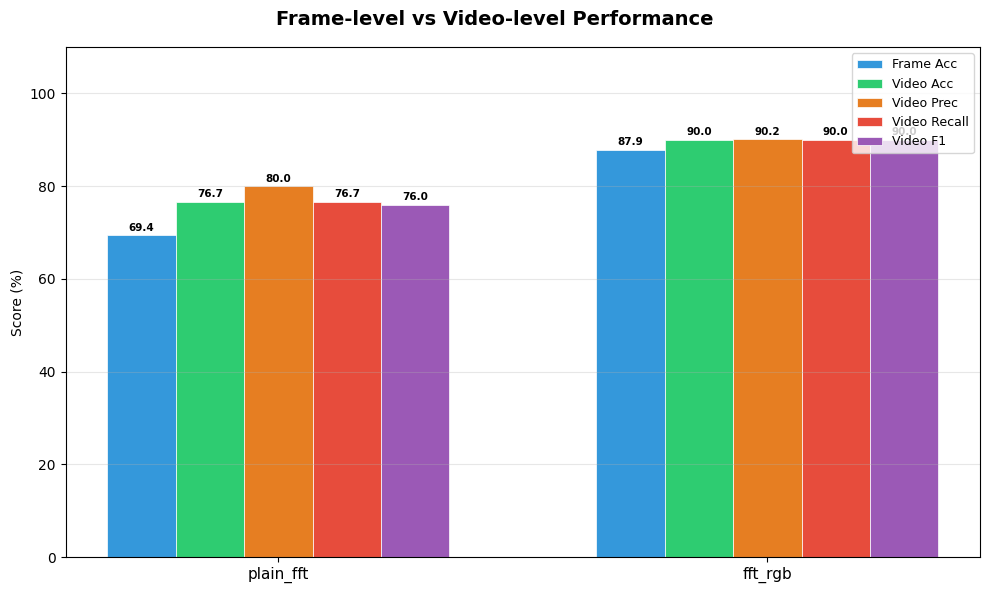

Saved -> /content/outputs_fft/video_level_comparison.png

Best method: fft_rgb  (90.00% video accuracy)

Done. All outputs saved to: /content/outputs_fft


In [7]:
# Cell 6 - Video-level evaluation using majority voting
# Frames are grouped by their parent folder name (one folder per video),
# and the video-level prediction is the majority vote across its frames.

@torch.no_grad()
def evaluate_with_video_voting(model, loader):
    model.eval()
    dataset = loader.dataset

    frame_preds, frame_labels = [], []
    video_votes       = {}
    video_true_labels = {}

    for i in range(len(dataset)):
        img, true_label = dataset[i]
        path     = dataset.samples[i][0]
        vid_name = Path(path).parent.name

        img  = img.unsqueeze(0).to(DEVICE)
        pred = model(img).argmax(1).item()

        frame_preds.append(pred)
        frame_labels.append(true_label)

        if vid_name not in video_votes:
            video_votes[vid_name]       = []
            video_true_labels[vid_name] = true_label
        video_votes[vid_name].append(pred)

    video_preds, video_labels = [], []
    for vid, votes in video_votes.items():
        majority = Counter(votes).most_common(1)[0][0]
        video_preds.append(majority)
        video_labels.append(video_true_labels[vid])

    return frame_preds, frame_labels, video_preds, video_labels


def print_video_report(method_name, frame_preds, frame_labels, video_preds, video_labels):
    sep = "=" * 64
    print(f"\n{sep}")
    print(f"  Method : {method_name}")
    print(sep)
    for level, preds, labels in [
            ("FRAME-level", frame_preds, frame_labels),
            ("VIDEO-level (majority vote)", video_preds, video_labels)]:
        acc  = accuracy_score (labels, preds)
        prec = precision_score(labels, preds, average="macro", zero_division=0)
        rec  = recall_score   (labels, preds, average="macro", zero_division=0)
        f1   = f1_score       (labels, preds, average="macro", zero_division=0)
        print(f"\n  -- {level} --")
        print(f"     Samples   : {len(labels)}")
        print(f"     Accuracy  : {acc * 100:.2f}%")
        print(f"     Precision : {prec * 100:.2f}%  (macro)")
        print(f"     Recall    : {rec * 100:.2f}%  (macro)")
        print(f"     F1-score  : {f1 * 100:.2f}%  (macro)")
        print()
        print(classification_report(labels, preds, target_names=CLASS_NAMES,
                                     zero_division=0, digits=4))
    print(sep)


# ---- Run video-level evaluation on the test set for both models -----------

ALL_VIDEO_RESULTS = {}

print("=" * 55)
print("VIDEO-LEVEL EVALUATION (TEST SET)")
print("=" * 55)

for method_name, ckpt_path, te_loader in [
        ("plain_fft", CKPT_PLAIN, te_plain),
        ("fft_rgb",   CKPT_RGB,   te_rgb),
]:
    print(f"\n>>> {method_name} - loading best checkpoint...")
    m = load_best_model(ckpt_path)
    fp, fl, vp, vl = evaluate_with_video_voting(m, te_loader)
    print_video_report(method_name, fp, fl, vp, vl)
    ALL_VIDEO_RESULTS[method_name] = dict(
        frame_acc  = accuracy_score (fl, fp),
        video_acc  = accuracy_score (vl, vp),
        video_rec  = recall_score   (vl, vp, average="macro", zero_division=0),
        video_prec = precision_score(vl, vp, average="macro", zero_division=0),
        video_f1   = f1_score       (vl, vp, average="macro", zero_division=0),
    )

# ---- Final comparison -------------------------------------------------------

print("\n" + "=" * 55)
print("FINAL COMPARISON")
print("=" * 55)

methods       = list(ALL_VIDEO_RESULTS.keys())
metrics_keys  = ["frame_acc", "video_acc", "video_prec", "video_rec", "video_f1"]
metric_labels = ["Frame Acc", "Video Acc", "Video Prec", "Video Recall", "Video F1"]

header = f"{'Method':<24}" + "".join(f"{m:>14}" for m in metric_labels)
print("\n" + "-" * len(header))
print(header)
print("-" * len(header))
for mth in methods:
    r   = ALL_VIDEO_RESULTS[mth]
    row = f"{mth:<24}" + "".join(f"{r[k] * 100:>13.2f}%" for k in metrics_keys)
    print(row)
print("-" * len(header))

x      = np.arange(len(methods))
width  = 0.14
colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c", "#9b59b6"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Frame-level vs Video-level Performance", fontsize=14, fontweight="bold")

for i, (key, lbl, col) in enumerate(zip(metrics_keys, metric_labels, colors)):
    vals = [ALL_VIDEO_RESULTS[m][key] * 100 for m in methods]
    bars = ax.bar(x + (i - 2) * width, vals, width, label=lbl,
                   color=col, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.1f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 110)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "video_level_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {path}")

best_method = max(methods, key=lambda m: ALL_VIDEO_RESULTS[m]["video_acc"])
best_acc    = ALL_VIDEO_RESULTS[best_method]["video_acc"] * 100
print(f"\nBest method: {best_method}  ({best_acc:.2f}% video accuracy)")
print("\nDone. All outputs saved to:", OUTPUT_DIR)